In [ ]:
import torch

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('GPU: Not available — running on CPU')
    print('Note: Data exploration is fine on CPU. RoBERTa training (Notebook 02) will be slow without GPU.')

PyTorch version: 2.6.0+cu124
CUDA available:  True
GPU:             NVIDIA GeForce RTX 3060 Laptop GPU
VRAM:            6.4 GB


In [2]:
import sys
import os
sys.path.append(os.path.abspath('../src'))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from data_loader import (load_edos_data,print_class_distribution,TASK_A_LABELS, TASK_B_LABELS,TASK_A_ID2LABEL, TASK_B_ID2LABEL)

DATA_DIR ='../data/'
RESULTS_DIR='../results/'
os.makedirs(RESULTS_DIR, exist_ok=True)
print('Setup complete.')

c:\Users\Ashwin Nair\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete.


In [5]:
train_df, dev_df, test_df=load_edos_data(DATA_DIR, task='A')
print(f'Train: {len(train_df)}, Dev: {len(dev_df)}, Test: {len(test_df)}')
print(f'Total: {len(train_df) + len(dev_df) + len(test_df)}')

Train: 14000, Dev: 2000, Test: 4000
Total: 20000


In [6]:
train_df.head(10)

,rewire_id,text,label_sexist,label_category,label_vector,split,label,label_id
0,sexism2022_english-16993,"Then, she's a keeper. 😉",not sexist,none,none,train,not sexist,0
1,sexism2022_english-13149,This is like the Metallica video where the poo...,not sexist,none,none,train,not sexist,0
2,sexism2022_english-13021,woman?,not sexist,none,none,train,not sexist,0
3,sexism2022_english-14998,Unlicensed day care worker reportedly tells co...,not sexist,none,none,train,not sexist,0
4,sexism2022_english-7228,[USER] Leg day is easy. Hot girls who wear min...,sexist,3. animosity,3.3 backhanded gendered compliments,train,sexist,1
5,sexism2022_english-4196,I don't know if you should avoid this one or e...,not sexist,none,none,train,not sexist,0
6,sexism2022_english-872,I get a new pussy every other week or whenever...,sexist,2. derogation,2.3 dehumanising attacks & overt sexual object...,train,sexist,1
7,sexism2022_english-11318,Release that shit,not sexist,none,none,train,not sexist,0
8,sexism2022_english-11688,Making games is a better cope. If you like gam...,not sexist,none,none,train,not sexist,0
9,sexism2022_english-19587,Guaranteed she chimped after being denied use ...,not sexist,none,none,train,not sexist,0


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14000 entries, 0 to 13999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   rewire_id       14000 non-null  object
 1   text            14000 non-null  object
 2   label_sexist    14000 non-null  object
 3   label_category  14000 non-null  object
 4   label_vector    14000 non-null  object
 5   split           14000 non-null  object
 6   label           14000 non-null  object
 7   label_id        14000 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 875.1+ KB


In [ ]:
for name, df in [('Train', train_df), ('Dev', dev_df), ('Test', test_df)]:
    print_class_distribution(df, name, task='A')

Task A : Train split (14000 posts)
not sexist                                    10602 (75.7%)
sexist                                         3398 (24.3%)
Task A : Dev split (2000 posts)
not sexist                                     1514 (75.7%)
sexist                                          486 (24.3%)
Task A : Test split (4000 posts)
not sexist                                     3030 (75.8%)
sexist                                          970 (24.2%)


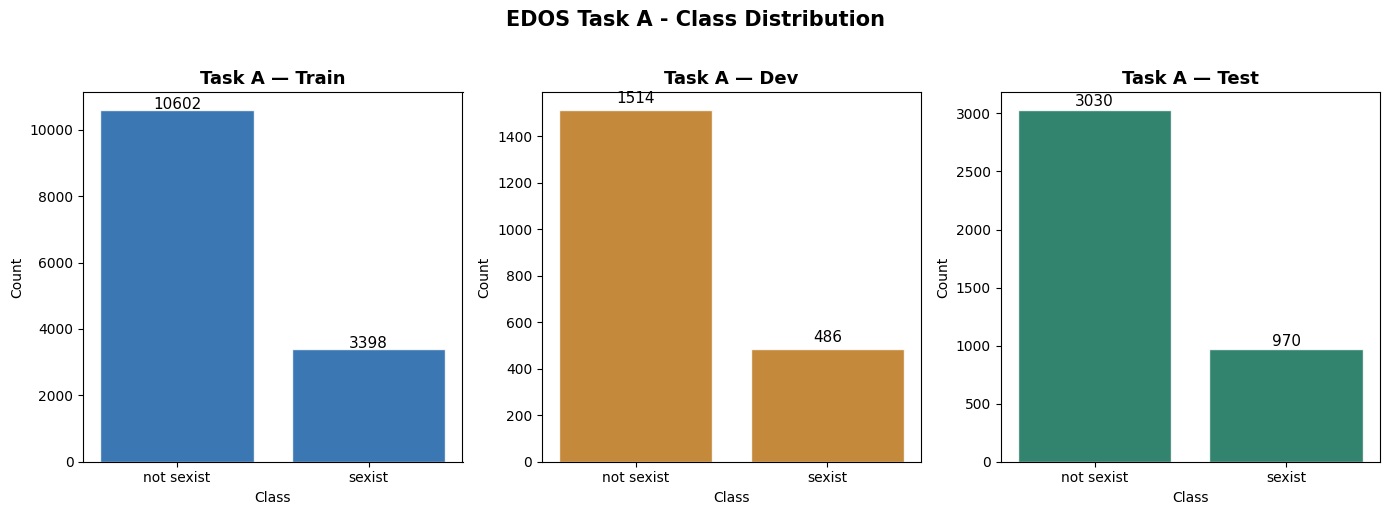

Saved.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
splits=[('Train', train_df), ('Dev', dev_df), ('Test', test_df)] ## Create a list of tuples containing the split name and corresponding DataFrame
colors=['#185FA5', '#BA7517', '#0F6E56']
for ax, (name, df), color in zip(axes, splits, colors):
    counts=df['label'].value_counts()
    ax.bar(counts.index, counts.values, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'Task A — {name}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_xlabel('Class')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 30, str(v), ha='center', fontsize=11)
plt.suptitle('EDOS Task A - Class Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}task_A_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

## For Task B (Taking only sexist posts)

In [ ]:
train_b, dev_b, test_b = load_edos_data(DATA_DIR, task='B') ## Load Task B data
print(f'Train: {len(train_b)} | Dev: {len(dev_b)} | Test: {len(test_b)}')

Train: 3398 | Dev: 486 | Test: 970


The numbers are matching from Task A

In [11]:
for name, df in [('Train', train_b), ('Dev', dev_b), ('Test', test_b)]:
    print_class_distribution(df, name, task='B')

Task B : Train split (3398 posts)
1. threats, plans to harm and incitement        310 (9.1%)
2. derogation                                  1590 (46.8%)
3. animosity                                   1165 (34.3%)
4. prejudiced discussions                       333 (9.8%)
Task B : Dev split (486 posts)
1. threats, plans to harm and incitement         44 (9.1%)
2. derogation                                   227 (46.7%)
3. animosity                                    167 (34.4%)
4. prejudiced discussions                        48 (9.9%)
Task B : Test split (970 posts)
1. threats, plans to harm and incitement         89 (9.2%)
2. derogation                                   454 (46.8%)
3. animosity                                    333 (34.3%)
4. prejudiced discussions                        94 (9.7%)


Again, the distubution is equal among all the 3 splits

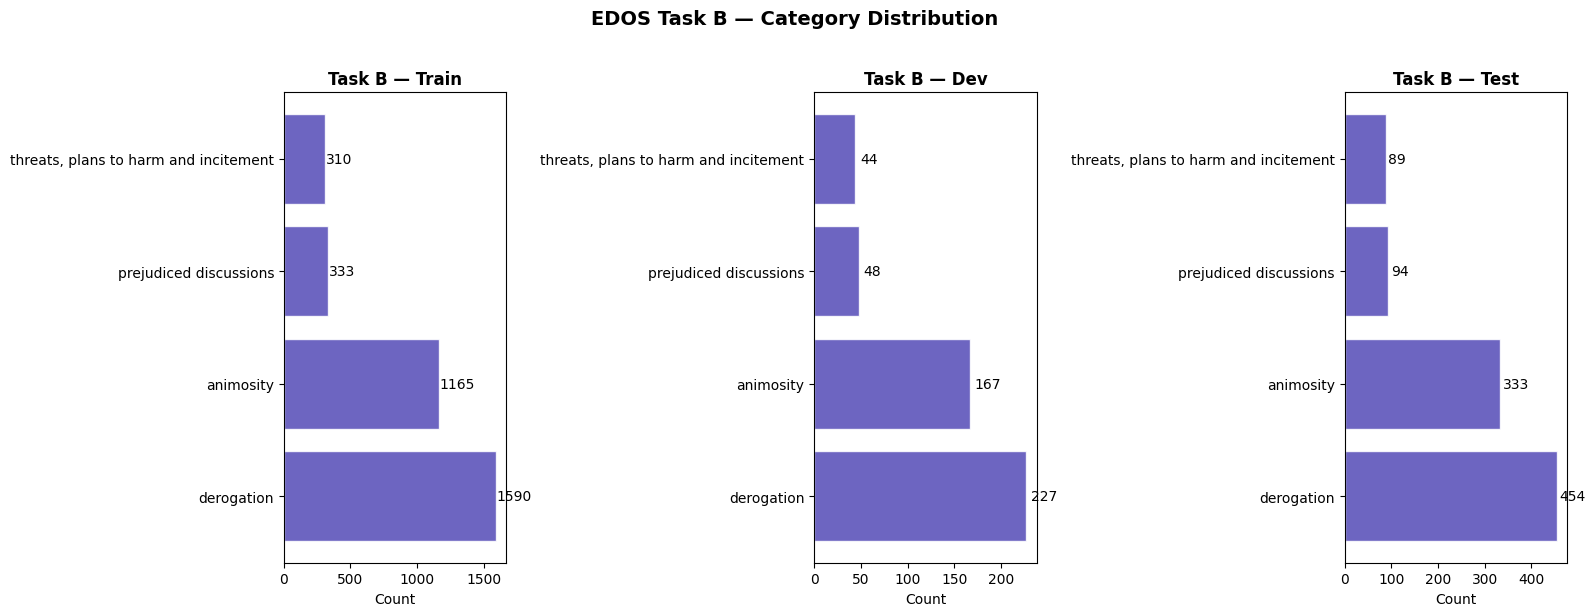

Saved.


In [ ]:
fig, axes=plt.subplots(1, 3, figsize=(16, 6))
splits_b = [('Train', train_b), ('Dev', dev_b), ('Test', test_b)]

for ax, (name, df) in zip(axes, splits_b): 
    counts = df['label'].value_counts()
    short_labels = [l.split('. ')[1] if '. ' in l else l for l in counts.index] ## Shorten labels for better visualization
    ax.barh(short_labels, counts.values, color='#534AB7', alpha=0.85, edgecolor='white')
    ax.set_title(f'Task B — {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(v + 5, i, str(v), va='center', fontsize=10)

plt.suptitle('EDOS Task B — Category Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}task_B_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

### Class Imbalance

In [ ]:
task_a_counts=train_df['label'].value_counts() ## Get counts of each category in Task A training data
task_b_counts=train_b['label'].value_counts() ## Get counts of each category in Task B training data

ratio_a=task_a_counts.max() / task_a_counts.min() ## Calculate imbalance ratio for Task A
ratio_b=task_b_counts.max() / task_b_counts.min() ## Calculate imbalance ratio for Task B

print(f'Task A imbalance ratio: {ratio_a:.2f}x')
print(f'Task B imbalance ratio: {ratio_b:.2f}x')
print(f'\nTask B category counts (training):')
print(task_b_counts.to_string())

Task A imbalance ratio: 3.12x
Task B imbalance ratio: 5.13x

Task B category counts (training):
label
2. derogation                               1590
3. animosity                                1165
4. prejudiced discussions                    333
1. threats, plans to harm and incitement     310


Text Length Analysis

In [ ]:
train_df['text_length'] = train_df['text'].apply(lambda x: len(x.split())) ## Calculate text length in words for each entry in the training set

print('Word Count):')
print(train_df['text_length'].describe().round(1).to_string()) ## Print descriptive statistics for text length in the training set

Word Count):
count    14000.0
mean        23.4
std         11.7
min          1.0
25%         14.0
50%         22.0
75%         33.0
max         55.0


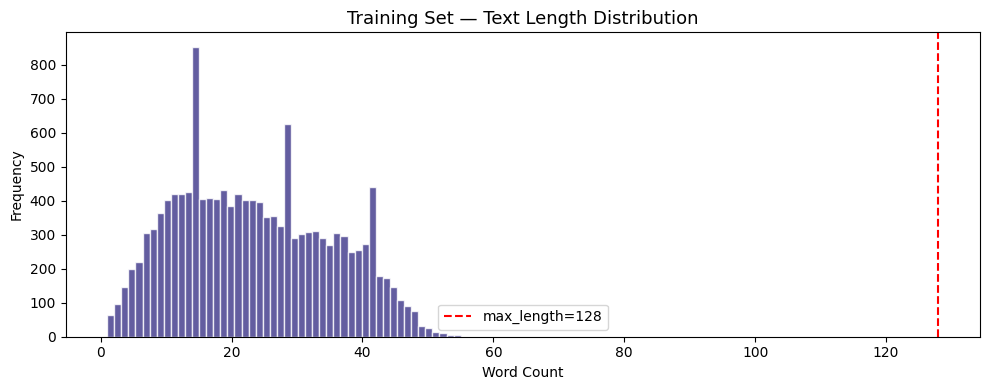

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train_df['text_length'], bins=50, color='#3C3489', alpha=0.8, edgecolor='white') ### Plot histogram of text lengths in the training set
ax.axvline(x=128, color='red', linestyle='--', linewidth=1.5, label='max_length=128') ## Add a vertical line at x=128 to indicate the maximum length used for RoBERTa training
ax.set_title('Training Set — Text Length Distribution', fontsize=13)
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

This means our Roberta Tokenizer won't miss any detail

In [ ]:
print('Sample posts per Task B category:\n')
for label in task_b_counts.index: 
    sample = train_b[train_b['label'] == label]['text'].sample(1, random_state=42).values[0] ## Get a random sample post for the current label
    short  = label.split('. ')[1] if '. ' in label else label ### Shorten the label for display
    print(f'[{short.upper()}]') ## Print the shortened label in uppercase
    print(f'  {sample[:200]}') ### Print the first 200 characters of the sample post
    print()

Sample posts per Task B category:

[DEROGATION]
  Didn't they used to burn these bitches... er witches.

[ANIMOSITY]
  I had a girlfriend who went on and on about how women were so much better at multitasking. In the end I had to say "if you're so good at multitasking then how come you can't sit down and shut up"

[PREJUDICED DISCUSSIONS]
  I probably wouldn't brag about that because usually when women make those choices they end up either being single moms or knowing the domestic violence hotline number extremely well.

[THREATS, PLANS TO HARM AND INCITEMENT]
  lock her ass up



Data Quality Checks

In [20]:
for name, df in [('Train', train_df), ('Dev', dev_df), ('Test', test_df)]:
    print(f'\n{name}:')
    print(f'  Null texts:      {df["text"].isna().sum()}')
    print(f'  Duplicate texts: {df["text"].duplicated().sum()}')
    print(f'  Empty texts:     {(df["text"].str.strip() == "").sum()}')
    print(f'  Total rows:      {len(df)}')


Train:
  Null texts:      0
  Duplicate texts: 0
  Empty texts:     0
  Total rows:      14000

Dev:
  Null texts:      0
  Duplicate texts: 0
  Empty texts:     0
  Total rows:      2000

Test:
  Null texts:      0
  Duplicate texts: 0
  Empty texts:     0
  Total rows:      4000


In [22]:
print(f'Task A imbalance ratio: {ratio_a:.2f}x')
print(f'Task B imbalance ratio: {ratio_b:.2f}x')
print(task_b_counts.to_string())

Task A imbalance ratio: 3.12x
Task B imbalance ratio: 5.13x
label
2. derogation                               1590
3. animosity                                1165
4. prejudiced discussions                    333
1. threats, plans to harm and incitement     310


In [23]:
print(train_df['text_length'].describe().round(1).to_string())
print(f"95th percentile: {train_df['text_length'].quantile(0.95):.0f} words")

count    14000.0
mean        23.4
std         11.7
min          1.0
25%         14.0
50%         22.0
75%         33.0
max         55.0
95th percentile: 43 words
